# GPT-2

In [96]:
import torch
import torch.nn as nn
from library.multi_head_attention import MultiHeadAttention

In [97]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Sentence length
    "emb_dim": 768,          # Embedding dimension - word vector size
    "n_heads": 12,           # Number of attention heads
    "n_layers": 12,          # Number of layers 
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": False        # Query-Key-Value bias
}

## Transformer Block

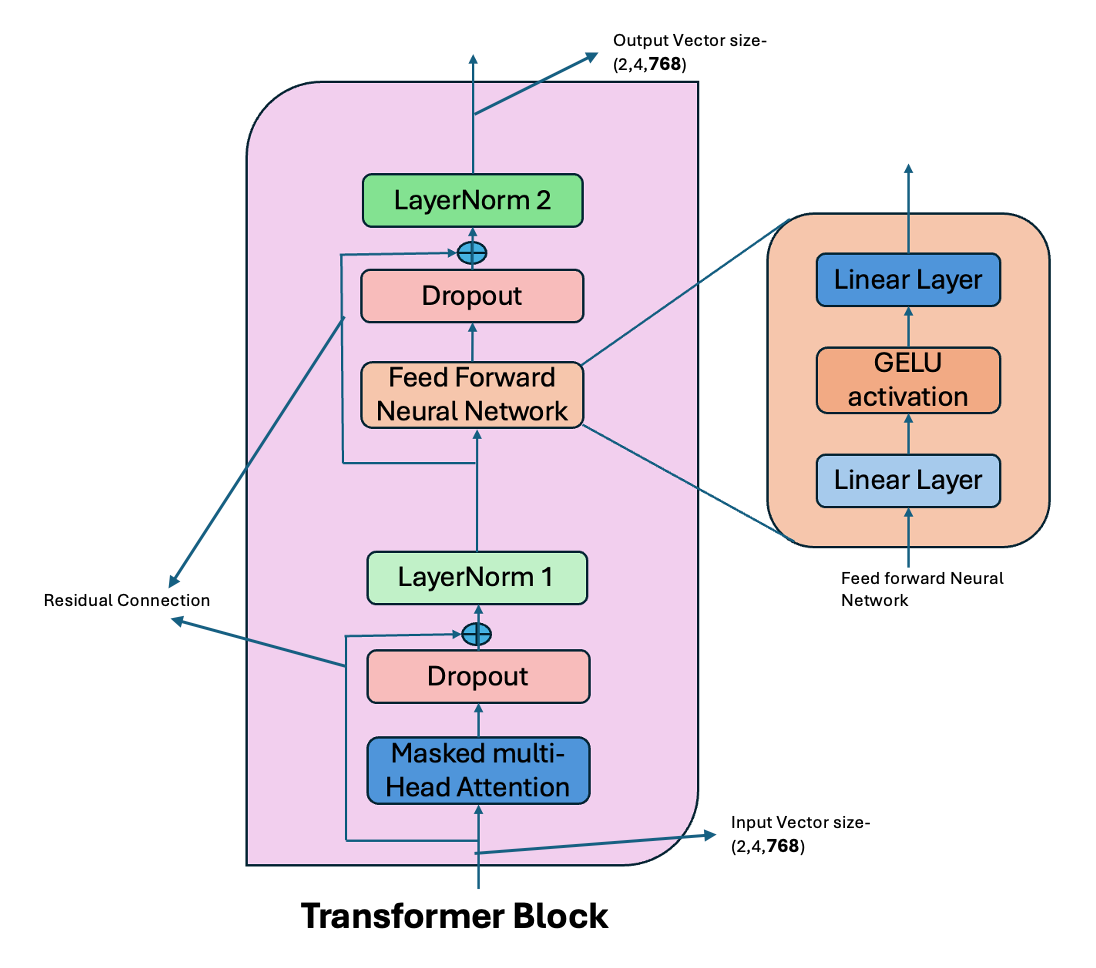

To implement the transformer block I need to do the following
- Layer normalization
- Redidual Connection
- Feed Forward Network
- GelU Activation function

### Layer Normalization
The main idea behind layer normalization is to adjust the activations of a neural network layer to have a mean of 0 and a variance of 1, also known as unit variance.

In [98]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

### GELU Activation

GPT-2 uses the tanh approximation of GELU:

$$\text{GELU}(x) = x \cdot \Phi(x) = x \cdot \frac{1}{2}\left[1 + \text{erf}\left(\frac{x}{\sqrt{2}}\right)\right]$$

Tanh approximation used in practice:

$$\text{GELU}(x) \approx 0.5 \cdot x \cdot \left(1 + \tanh\left(\sqrt{\frac{2}{\pi}}\left(x + 0.044715\, x^3\right)\right)\right)$$

In [99]:
class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh((2 / torch.pi) ** 0.5 * (x + 0.044715 * x ** 3)))

### Feed Forward Network

This expansion is followed by a nonlinear GELU activation and then a contraction back to the original dimension with the second linear transformation. Such a design allows for the exploration of a richer representation space.

In [100]:
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(config["emb_dim"], 4 * config["emb_dim"]),
            GELU(),
            nn.Linear(4 * config["emb_dim"], config["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

### Transformer

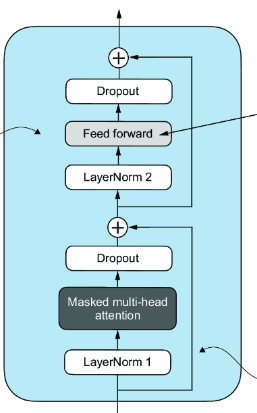

In [101]:
class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attention = MultiHeadAttention(
            d_in=config["emb_dim"],
            d_out=config["emb_dim"],
            context_length=config["context_length"],
            dropout=config["drop_rate"],
            num_heads=config["n_heads"],
            qkv_bias=config["qkv_bias"]
        )
        self.feedforward = FeedForward(config)
        self.norm1 = LayerNorm(config["emb_dim"])
        self.norm2 = LayerNorm(config["emb_dim"])
        self.drop_shortcut = nn.Dropout(config["drop_rate"])

    def forward(self, input):
        shortcut = input
        result = self.norm1(input)
        result = self.attention(result)
        print(f"Attention output shape: {result.shape}")
        result = self.drop_shortcut(result)
        result = result + shortcut      

        shortcut = result         
        result = self.norm2(result)
        result = self.feedforward(result)
        result = self.drop_shortcut(result)
        result = result + shortcut      
        return result

In [102]:
x = torch.rand(2, 4, 768)         
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Attention output shape: torch.Size([2, 4, 768])
Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


## GPT Model

In [103]:
class GPTModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.token_emb = nn.Embedding(config["vocab_size"], config["emb_dim"])
        self.position_emb = nn.Embedding(config["context_length"], config["emb_dim"])
        self.drop_emb = nn.Dropout(config["drop_rate"])

        self.transformer_blocks = nn.Sequential(*[TransformerBlock(config) for _ in range(config["n_layers"])])
        self.final_norm = LayerNorm(config["emb_dim"])
        self.out_head = nn.Linear(config["emb_dim"], config["vocab_size"], bias=False )

    def forward(self, in_idx):
        _, seq_len = in_idx.shape
        token_embeds = self.token_emb(in_idx)
 
        position_embeds = self.position_emb(torch.arange(seq_len, device=in_idx.device))
        result = token_embeds + position_embeds
        result = self.drop_emb(result)
        result = self.transformer_blocks(result)
        result = self.final_norm(result)
        logits = self.out_head(result)
        return logits

In [104]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

NameError: name 'batch' is not defined